<a href="https://colab.research.google.com/github/puremeant/ML-assignment/blob/main/ML_midterm.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Resign counts: resign
0    11428
1     3571
Name: count, dtype: int64
Resign proportion: resign
0    0.761917
1    0.238083
Name: proportion, dtype: float64
Coefficient: satisfaction   -4.0519
evaluation      0.6455
project        -0.3000
workhour        0.0042
years           0.2264
accident       -1.5484
promotion      -1.7048
dtype: float64
Logistic: [0 0 0 0 0 0 0 1 0 0]
[[0.92086235 0.07913765]
 [0.73841149 0.26158851]
 [0.94437323 0.05562677]
 [0.58523341 0.41476659]
 [0.94525164 0.05474836]
 [0.93912818 0.06087182]
 [0.88582697 0.11417303]
 [0.47564148 0.52435852]
 [0.9129939  0.0870061 ]
 [0.56825359 0.43174641]]
Accuracy: 0.7676666666666667
Confusion matrix:
[[2120  166]
 [ 531  183]]
Precision: 0.5243553008595988
Recall: 0.25630252100840334
F1 score: 0.3443085606773283
              precision    recall  f1-score   support

           0       0.80   

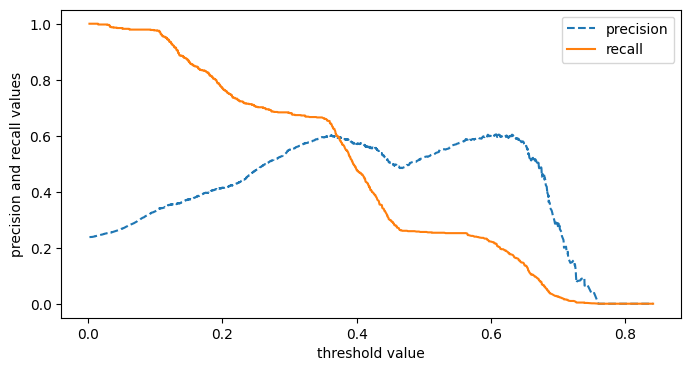

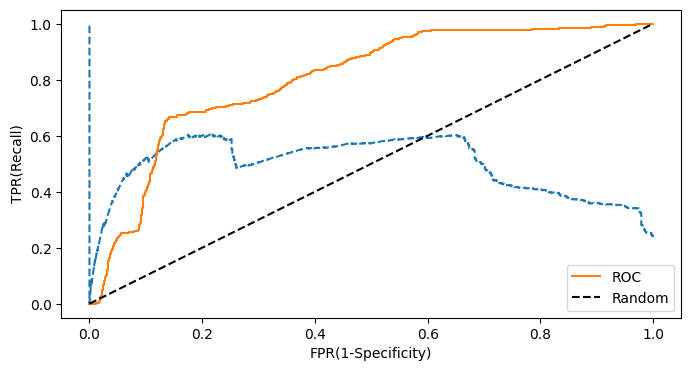

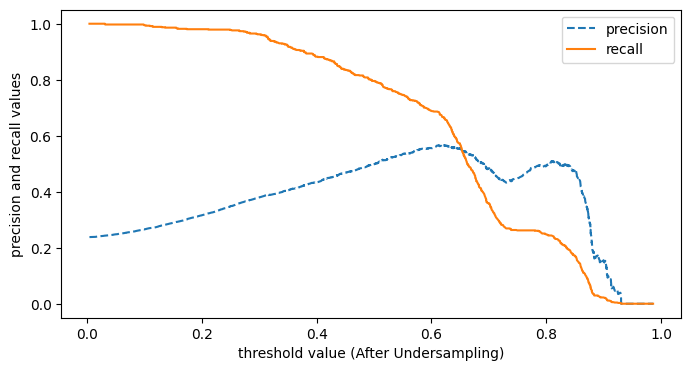

              precision    recall  f1-score   support

           0       0.92      0.75      0.83      2286
           1       0.50      0.80      0.61       714

    accuracy                           0.76      3000
   macro avg       0.71      0.77      0.72      3000
weighted avg       0.82      0.76      0.78      3000

satisfaction    False
evaluation      False
project         False
workhour        False
years           False
accident        False
resign          False
promotion       False
dtype: bool
       satisfaction    evaluation       project      workhour         years  \
count  14999.000000  14999.000000  14999.000000  14999.000000  14999.000000   
mean       0.612834      0.716102      3.803054    201.050337      3.498233   
std        0.248631      0.171169      1.232592     49.943099      1.460136   
min        0.090000      0.360000      2.000000     96.000000      2.000000   
25%        0.440000      0.560000      3.000000    156.000000      3.000000   
50%        

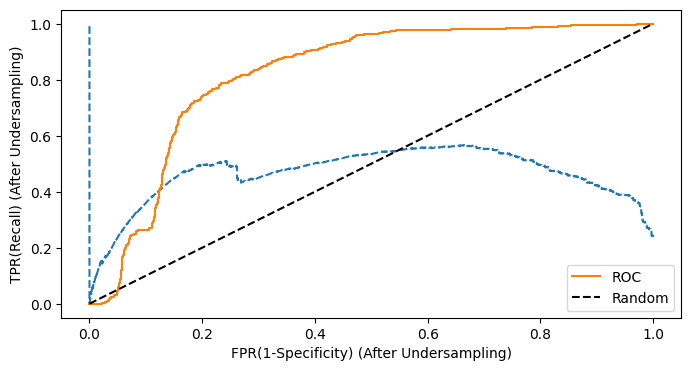

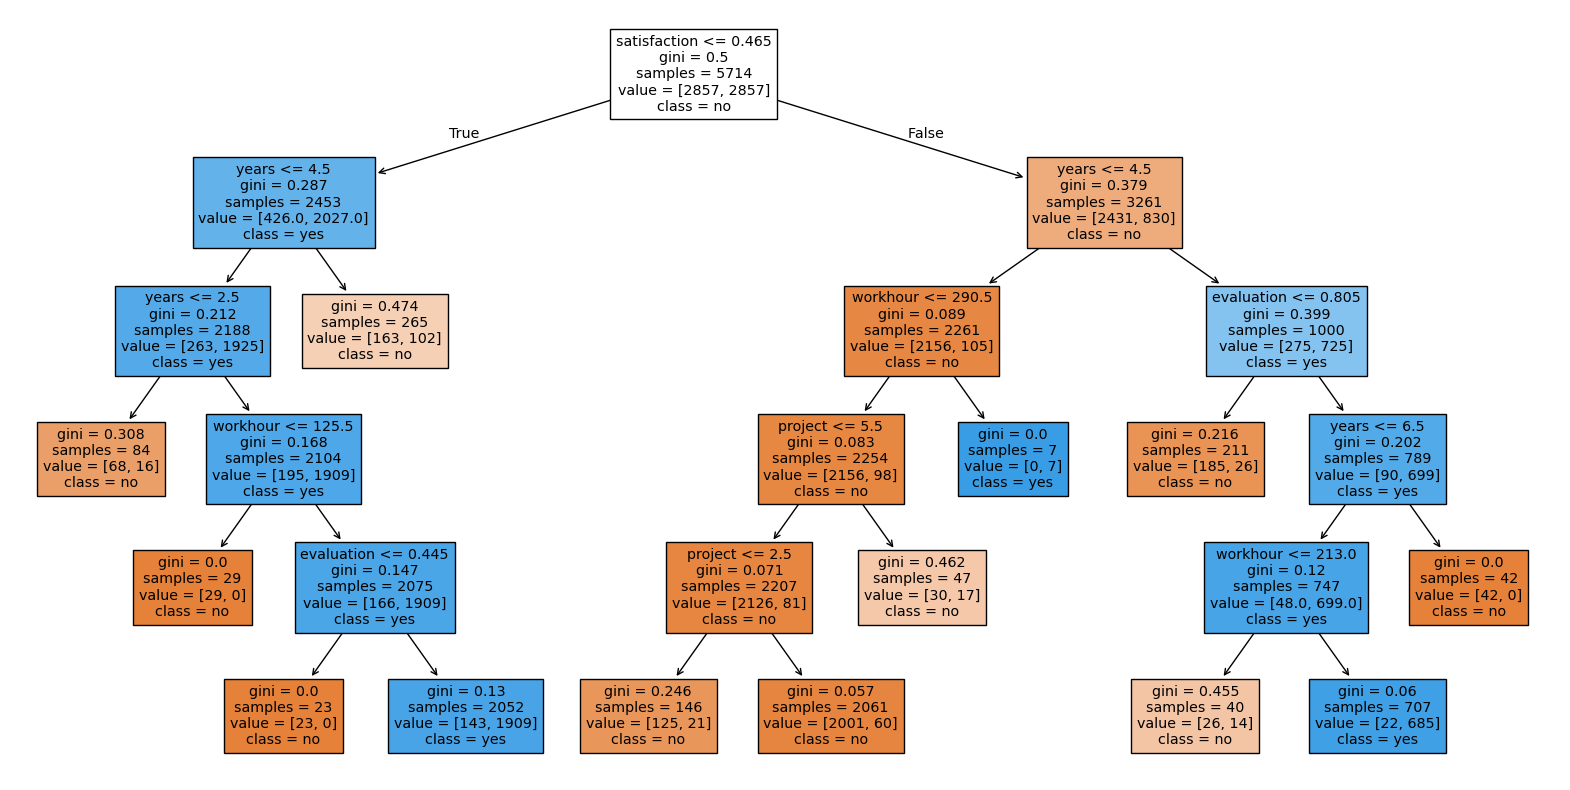

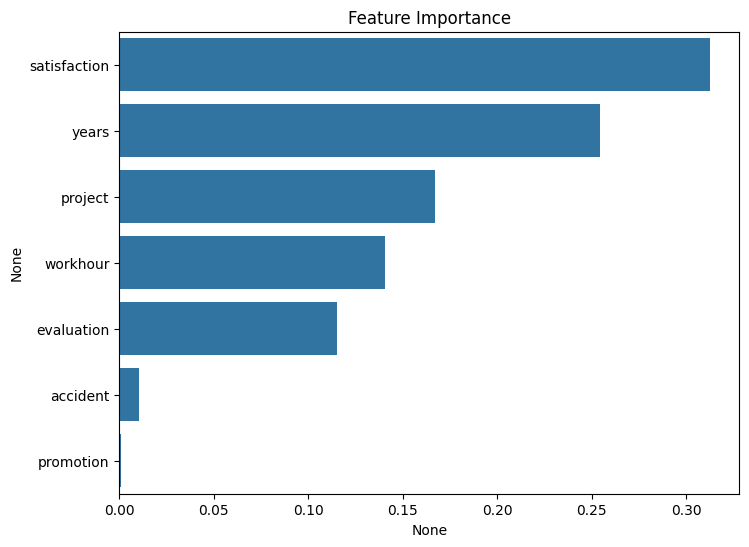

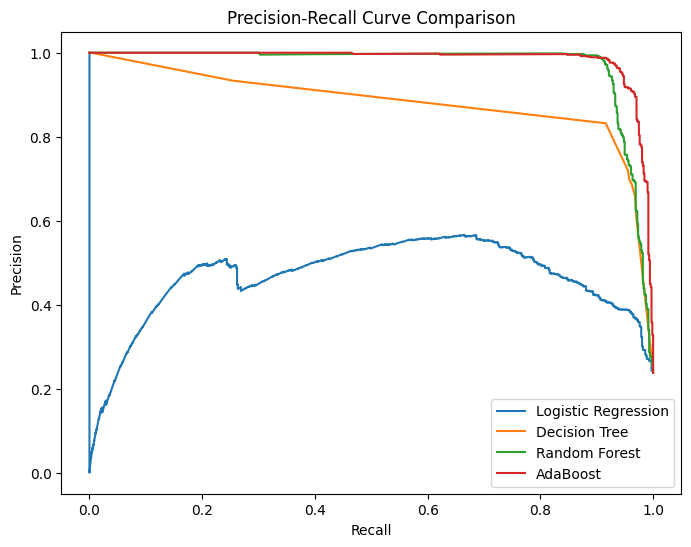

AdaBoost


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier

# Access to the file
from google.colab import drive
drive.mount('/content/drive')
df = pd.read_csv('/content/drive/MyDrive/resign.csv')
#df.info() # Check data

# --- (1) Check the class proportions of the resign variable
print("Resign counts:", df['resign'].value_counts())
print("Resign proportion:", df['resign'].value_counts(normalize=True))
##The target variable resign is imbalanced because the number of employees who did not resign is larger than the number of employees who resigned.
##Therefore, I used stratified sampling when splitting the data into training and test sets.
##However, the imbalance was not extremely severe, so I first trained the models without under-sampling and evaluated their precision, recall, and F1 score on the test set.

# --- (2) Randomly split the full dataset into tr 80%, ts 20%, use stratified sampling.
X= df.drop('resign', axis=1) #Set features, except for a target variable, 'resign'.
y = df['resign']
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split( X, y, test_size=0.2, random_state=0, stratify=y)

# --- (3) Train a Logistic Regression model using the training data
from sklearn.linear_model import LogisticRegression
lr_rsg = LogisticRegression(max_iter=1000, random_state=0)
lr_rsg.fit(X_train, y_train)
lr_rsg.coef_

coeff = pd.Series(data= np.round(lr_rsg.coef_[0], decimals=4), index=['satisfaction', 'evaluation','project','workhour','years','accident','promotion'])
print("Coefficient:", coeff)

y_pred = lr_rsg.predict(X_test)
print("Logistic:", y_pred[:10])
y_pred_proba = lr_rsg.predict_proba(X_test)
print(y_pred_proba[:10])

# Check accuracy, precision, recall and f1 scores
from sklearn.metrics import accuracy_score, confusion_matrix, precision_score, recall_score, f1_score
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Confusion matrix:")
print(confusion_matrix(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1 score:", f1_score(y_test, y_pred))
## Recall and f1 scores are relatively low, implying that the model has difficulty identifying employees who actually resigned.
## Although the model may predict many non-resigned employees, it is less effective at detecting employees who actually resigned, which is our main concern.

# Precision-Recall values and PR Curve
from sklearn.metrics import precision_recall_curve
y_pred_proba1 = y_pred_proba[: ,1]
precisions, recalls, thres = precision_recall_curve(y_test, y_pred_proba1)
thres_n = thres.shape[0]
np.c_[precisions[ : thres_n], recalls[ : thres_n], thres]

import matplotlib.pyplot as plt
plt.figure(figsize= (8,4))
plt.plot(thres, precisions[0:thres_n], linestyle='--', label='precision')
plt.plot(thres, recalls[0:thres_n], label='recall')
plt.xlabel('threshold value')
plt.ylabel('precision and recall values')
plt.legend()

plt.figure(figsize=(8,4))
plt.plot(recalls, precisions, linestyle='--')
plt.xlabel('recall')
plt.ylabel('precision')

#AUC and ROC
from sklearn.metrics import auc
auc(recalls, precisions)

from sklearn.metrics import roc_curve
fprs, tprs, thresholds = roc_curve(y_test, y_pred_proba1)
np.c_[fprs, tprs, np.round(thresholds, decimals=3)][:10]

plt.plot(fprs, tprs, label='ROC')
plt.plot( [0,1], [0,1], 'k--', label='Random')
plt.xlabel('FPR(1-Specificity)')
plt.ylabel('TPR(Recall)')
plt.legend()

from sklearn.metrics import roc_auc_score
roc_auc_score(y_test, y_pred_proba1)

from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred))
## Although the overall accuracy is 0.77, the model performs poorly on the resigned class. The recall for class 1 is only 0.26, meaning that the model misses many employees who actually resigned.
## Since identifying resigned employees is the main concern of this analysis, additional methods such as under-sampling can be considered.

# --- (3) AGAIN, Train a Logistic Regression model AFTER applying under-sampling
from imblearn.under_sampling import RandomUnderSampler
rus = RandomUnderSampler(random_state=0)
X_train_under, y_train_under = rus.fit_resample(X_train, y_train)
pd.Series(y_train_under).value_counts()

from sklearn.linear_model import LogisticRegression
lr_under = LogisticRegression(max_iter=1000, random_state=0)
lr_under.fit(X_train_under, y_train_under)
lr_under.coef_

coeff_under = pd.Series(data= np.round(lr_under.coef_[0], decimals=4), index=['satisfaction', 'evaluation','project','workhour','years','accident','promotion'])
print("Coefficient:", coeff_under)

y_pred_under = lr_under.predict(X_test)
print(y_pred_under[:10])
y_pred_proba_under = lr_under.predict_proba(X_test)
print(y_pred_proba_under[:10])

# Check accuracy, precision, recall and f1 scores
from sklearn.metrics import accuracy_score, confusion_matrix, precision_score, recall_score, f1_score
print("Accuracy:", accuracy_score(y_test, y_pred_under))
print("Confusion matrix:")
print(confusion_matrix(y_test, y_pred_under))
print("Precision:", precision_score(y_test, y_pred_under))
print("Recall:", recall_score(y_test, y_pred_under))
print("F1 score:", f1_score(y_test, y_pred_under))
## f1 score incrased.

# Precision-Recall values and PR Curve
from sklearn.metrics import precision_recall_curve
y_pred_proba1_under = y_pred_proba_under[: ,1]
precisions_under, recalls_under, thres_under = precision_recall_curve(y_test, y_pred_proba1_under)
thres_n_under = thres_under.shape[0]
np.c_[precisions_under[:thres_n_under], recalls_under[:thres_n_under], thres_under]

import matplotlib.pyplot as plt
plt.figure(figsize= (8,4))
plt.plot(thres_under, precisions_under[0:thres_n_under], linestyle='--', label='precision')
plt.plot(thres_under, recalls_under[0:thres_n_under], label='recall')
plt.xlabel('threshold value (After Undersampling)')
plt.ylabel('precision and recall values')
plt.legend()
plt.show()

plt.figure(figsize=(8,4))
plt.plot(recalls_under, precisions_under, linestyle='--')
plt.xlabel('recall (After Undersampling)')
plt.ylabel('precision (After Undersampling)')

#AUC and ROC
from sklearn.metrics import auc
auc(recalls_under, precisions_under)

from sklearn.metrics import roc_curve
fprs_under, tprs_under, thresholds_under = roc_curve(y_test, y_pred_proba1_under)
np.c_[fprs_under, tprs_under, np.round(thresholds_under, decimals=3)][:10]

plt.plot(fprs_under, tprs_under, label='ROC')
plt.plot( [0,1], [0,1], 'k--', label='Random')
plt.xlabel('FPR(1-Specificity) (After Undersampling)')
plt.ylabel('TPR(Recall) (After Undersampling)')
plt.legend()

from sklearn.metrics import roc_auc_score
roc_auc_score(y_test, y_pred_proba1_under)

from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred_under))
## After undersampling, f1 score from 0.34 to 0.61, recall for class 1 from 0.26 to 0.79, impling the model improved at identifying employees who actually resigned.
## However, recall for class 0 slightly decreased as a trade-off.
## Precision still fluctuates and decreases at higher threshold values, making precision sensitive to small changes in the number of true positives and false positives..


# --- (4) Train a Decision Tree model using the training data. For hyperparameters, apply 5-fold cross-validation
print(df.isnull().any(axis=0)) ## Check NaN
print(df.describe()) ## basic summary statistics

from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.model_selection import GridSearchCV
parameters = {'max_depth': [3,4,5], 'min_samples_split' : [300, 500, 1000]}
dt_rsg= DecisionTreeClassifier(random_state=0)
grid_dt = GridSearchCV(dt_rsg, param_grid= parameters, cv=5, scoring='f1', refit=True )
grid_dt.fit(X_train_under, y_train_under)
scores_df = pd.DataFrame(grid_dt.cv_results_) #cross-validation results
print(scores_df.iloc [:,6:])
print(grid_dt.best_params_) # Best parameters and best CV score
print(grid_dt.best_score_)

## max_depth=5, min_samples_split=300 are best parameters. Applying best params.
## Using 5-fold cross-validation with F1-score as the scoring metric, the best decision tree parameters were selected from the parameter grid.
## The final decision tree model was then refitted using the best parameters and evaluated on the original test set.
dt_update = grid_dt.best_estimator_
y_pred_under_dt = dt_update.predict(X_test)
print(f1_score(y_test, y_pred_under_dt))


# --- (5) Visualize the tree obtained from the result of (4) and interpret it.
fig=plt.figure(figsize=(20,10))
plot_tree(dt_update, feature_names=X.columns, class_names=['no','yes'], filled=True);
## The first split of the decision tree is based on satisfaction, indicating that satisfaction is the most important variable for predicting resignation in this tree.
## Employees with satisfaction less than or equal to 0.465 are mostly classified as resigned (blue-colored). In particular, among employees with low satisfaction, those with years between 2.5 and 4.5, work hours greater than 125.5, and project numbers less than or equal to 2.5 are highly likely to resign.
## On the other hand, employees with satisfaction greater than 0.465 are generally classified as non-resigned (orange-colored). However, the tree also identifies another high-risk group (blue-colored in the satisfaction over 0.465): employees with higher satisfaction but more than 4.5 years at the company, high evaluation scores, and long work hours.
## OVerall, the decision tree suggests that resignation may be associated not only with low satisfaction but also with high workload among high-performing employees.


# --- (6) Train a Random Forest model using the training data. For the hyperparameters that need tuning, apply 5-fold cross-validation.
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV
parameters = {'n_estimators': [100, 300, 500], 'max_depth': [3,4,5], 'min_samples_split' : [300, 500, 1000]}
rf_rsg= RandomForestClassifier(random_state=0, oob_score=True, bootstrap=True)
grid_rf = GridSearchCV(rf_rsg, param_grid= parameters, cv=5, scoring='f1', refit=True)
grid_rf.fit(X_train_under, y_train_under)
scores_rf = pd.DataFrame(grid_rf.cv_results_) #cross-validation results
print(scores_rf.iloc [:,6:])
print(grid_rf.best_params_) # Best parameters and best CV score
print(grid_rf.best_score_)

## max_depth=5, min_samples_split=300, n_estimators=500 are best parameters. Applying best params.
## Using 5-fold cross-validation with F1-score as the scoring metric, the best random forest parameters were selected from the parameter grid.
## The final random forest model was then refitted using the best parameters and evaluated on the original test set.
rf_update = grid_rf.best_estimator_ # Best random forest model from GridSearchCV
y_pred_under_rf = rf_update.predict(X_test)
print(f1_score(y_test, y_pred_under_rf))


# --- (7) From the result of (6), obtain the feature importance values for each variable and interpret them.
feature_importances = np.mean( [tree.feature_importances_ for tree in rf_update.estimators_], axis=0)
import seaborn as sns
imp_values = feature_importances
imp_values = pd.Series(imp_values, index=X_train_under.columns)
imp_values = imp_values.sort_values(ascending=False)
plt.figure(figsize=(8,6))
plt.title('Feature Importance')
sns.barplot(x=imp_values, y=imp_values.index)
## The feature importance results show that satisfaction is the most important variable in the random forest model, contributing the most to predicting employee resignation.
## Years was the second most important variable, followed by project, workhour, and evaluation. In contrast, accident and promotion had very low importance values, suggesting that they contributed little to the model's prediction.
## Overall, the random forest model suggests that employee resignation is mainly associated with satisfaction, years, projects, working hours, and evaluation.
## However, feature importance does not imply causality; it only shows the relative contribution of each variable to prediction.


# --- (8) Train an AdaBoost model using the training data. For the hyperparameters that need tuning, apply 5-fold cross-validation on the training data.
from sklearn.ensemble import AdaBoostClassifier
parameters = {'n_estimators': [100, 300, 500], 'estimator__max_depth': [1,2,3]}
ada_rsg = AdaBoostClassifier(DecisionTreeClassifier(random_state=0), random_state=0)
grid_ada = GridSearchCV(ada_rsg, param_grid= parameters, cv=5, scoring='f1', refit=True)
grid_ada.fit(X_train_under, y_train_under)
scores_ada = pd.DataFrame(grid_ada.cv_results_) #cross-validation results
print(scores_ada.iloc [:,6:])
print("Best parameters:", grid_ada.best_params_) # Best parameters and best CV score
print("Best CV score:", grid_ada.best_score_)

## estimator_max_depth=3, n_estimators=500 are best parameters. Applying best params.
## The best AdaBoost parameters were selected using 5-fold cross-validation with F1-score as the scoring metric.
## The final AdaBoost model was then refitted using the best parameters and evaluated on the original test set.
ada_update = grid_ada.best_estimator_ # Best AdaBoost from GridSearchCV
y_pred_under_ada = ada_update.predict(X_test)
print("AdaBoost F1 Score:", f1_score(y_test, y_pred_under_ada))

# --- (9) Using the test data, compare the performance of the models from (3), (4), (6), and (8). For model comparison, use precision, recall, F1 score, and the precision-recall curve.
# Predictions
y_pred_under_lr = lr_under.predict(X_test)
y_pred_under_dt = dt_update.predict(X_test)
y_pred_under_rf = rf_update.predict(X_test)
y_pred_under_ada = ada_update.predict(X_test)
# Predicted probabilities for class 1
y_proba_under_lr = lr_under.predict_proba(X_test)[:, 1]
y_proba_under_dt = dt_update.predict_proba(X_test)[:, 1]
y_proba_under_rf = rf_update.predict_proba(X_test)[:, 1]
y_proba_under_ada = ada_update.predict_proba(X_test)[:, 1]

# Compare precision, recall, and F1 score
model_comparison = pd.DataFrame({'Model': ['Logistic Regression', 'Decision Tree', 'Random Forest', 'AdaBoost'],
    'Precision': [precision_score(y_test, y_pred_under_lr),
        precision_score(y_test, y_pred_under_dt),
        precision_score(y_test, y_pred_under_rf),
        precision_score(y_test, y_pred_under_ada)],
    'Recall': [recall_score(y_test, y_pred_under_lr),
        recall_score(y_test, y_pred_under_dt),
        recall_score(y_test, y_pred_under_rf),
        recall_score(y_test, y_pred_under_ada)],
    'F1 Score': [f1_score(y_test, y_pred_under_lr),
        f1_score(y_test, y_pred_under_dt),
        f1_score(y_test, y_pred_under_rf),
        f1_score(y_test, y_pred_under_ada)]})
print(model_comparison)
## Based on the test results, Random Forest achieved the highest F1 score with 0.934473.
## Since the dataset is imbalanced and the main goal is to identify resigned employees, F1 score and recall are more informative than accuracy alone. The precision-recall curve also shows that this model maintains a better balance between precision and recall compared to the other models.

# Precision-Recall curves for all models
plt.figure(figsize=(8, 6))
# Logistic Regression
prec_lr, rec_lr, thres_lr = precision_recall_curve(y_test, y_proba_under_lr)
plt.plot(rec_lr, prec_lr, label='Logistic Regression')
# Decision Tree
prec_dt, rec_dt, thres_dt = precision_recall_curve(y_test, y_proba_under_dt)
plt.plot(rec_dt, prec_dt, label='Decision Tree')
# Random Forest
prec_rf, rec_rf, thres_rf = precision_recall_curve(y_test, y_proba_under_rf)
plt.plot(rec_rf, prec_rf, label='Random Forest')
# AdaBoost
prec_ada, rec_ada, thres_ada = precision_recall_curve(y_test, y_proba_under_ada)
plt.plot(rec_ada, prec_ada, label='AdaBoost')

plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve Comparison')
plt.legend()
plt.show()

best_model = model_comparison.sort_values(by='F1 Score', ascending=False).iloc[0]['Model']
print(best_model)
## Among the models, the model with the highest F1 score was selected as the best-performing model.
## Since the goal is to identify employees who actually resigned, both recall and F1 score are important evaluation metrics.


# --- (10) For the best-performing model in (9), analyze how the F1 score changes as the threshold changes, and suggest an appropriate threshold considering F1 score.




# --- (11) Based on the result (9), state which model performs the best and explain why that model was able to predict the resign data well.

## (1) Check the class proportions of the resign variable
The class proportion shows that there are 11,428 observations for 0 and 3,571 observations for 1. Therefore, the dataset is quite imbalanced.
